In [41]:
# ============================================================
# STEP 1: IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier, plot_importance
import joblib


In [42]:
# ============================================================
# STEP 2: LOAD ALL CSV FILES
# ============================================================
# Pointing to the exact folder created in our feature extraction step
DATA_PATH = r"C:\Users\Ayush\Desktop\Coding World\Multi_Modal_SnatchDetection\Dataset\CSV_Extracted\Features"

all_files = [f for f in os.listdir(DATA_PATH) if f.endswith(".csv")]
print(f"📁 Found {len(all_files)} feature CSVs.")

df_list = []
for file in all_files:
    path = os.path.join(DATA_PATH, file)
    try:
        df = pd.read_csv(path)
        if not df.empty:
            df_list.append(df)
    except pd.errors.EmptyDataError:
        continue

if not df_list:
    raise ValueError("❌ No data found! Check your CSV files.")

df = pd.concat(df_list, ignore_index=True)

print(f"✅ Total windows (samples) loaded: {len(df)}")
df.loc[df['label'] == 10, 'label'] = 1
print("\n📊 Label Distribution:")
print(df['label'].value_counts())

📁 Found 398 feature CSVs.
✅ Total windows (samples) loaded: 18137

📊 Label Distribution:
label
0.0    17829
1.0      286
Name: count, dtype: int64


In [43]:
print("NaN in y:", y.isna().sum())
# Remove rows where label is missing
df = df[df['label'].notna()]
# Convert to integer
df['label'] = df['label'].astype(int)
print("NaN in y:", y.isna().sum())

NaN in y: 0
NaN in y: 0


In [66]:
# ============================================================
# STEP 3: FEATURE SELECTION
# ============================================================
# Drop metadata columns to isolate only the math/physics features
X = df.drop(columns=[
    "video_id",
    "window_id",
    "start_frame",
    "end_frame",
    "label",
    "avg_speed"
])

# Ensure all data is strictly numeric (safety net)
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
y = df["label"]


In [67]:
# ============================================================
# STEP 4: TRAIN-TEST SPLIT
# ============================================================
# stratify=y ensures both train and test sets get a fair share of label=1
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [68]:
# ============================================================
# STEP 5: HANDLE IMBALANCE
# ============================================================
num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()

if num_pos == 0:
    raise ValueError("❌ No positive (label=1) samples in training set! You must manually label your CSVs first.")

scale_pos_weight = num_neg / num_pos
print(f"\n⚖️ Calculated scale_pos_weight: {scale_pos_weight:.2f}")


⚖️ Calculated scale_pos_weight: 62.28


In [69]:
# ============================================================
# STEP 6: TRAIN MODEL (XGBOOST)
# ============================================================
print("🚀 Training XGBoost Model...")
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)
print("✅ Model training complete.")

🚀 Training XGBoost Model...
✅ Model training complete.


In [70]:
# ============================================================
# STEP 7: EVALUATION WITH CUSTOM THRESHOLD
# ============================================================
# Get the raw probabilities instead of the final 0/1 prediction
y_probs = model.predict_proba(X_test)[:, 1]

# 🎛️ TUNE THIS: Raise the threshold from the default 0.65
CUSTOM_THRESHOLD = 0.85

# Apply the custom threshold
y_pred_custom = (y_probs >= CUSTOM_THRESHOLD).astype(int)

print(f"\n📊 Classification Report (Threshold: {CUSTOM_THRESHOLD}):")
print(classification_report(y_test, y_pred_custom))

print("\n📉 Confusion Matrix:")
print("                 Predicted Normal (0) | Predicted Snatch (1)")
print(f"Actual Normal(0) |        {confusion_matrix(y_test, y_pred_custom)[0][0]}            |          {confusion_matrix(y_test, y_pred_custom)[0][1]}")
print(f"Actual Snatch(1) |        {confusion_matrix(y_test, y_pred_custom)[1][0]}            |          {confusion_matrix(y_test, y_pred_custom)[1][1]}")


📊 Classification Report (Threshold: 0.85):
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3566
           1       0.28      0.67      0.39        57

    accuracy                           0.97      3623
   macro avg       0.64      0.82      0.69      3623
weighted avg       0.98      0.97      0.97      3623


📉 Confusion Matrix:
                 Predicted Normal (0) | Predicted Snatch (1)
Actual Normal(0) |        3468            |          98
Actual Snatch(1) |        19            |          38


<Figure size 1000x600 with 0 Axes>

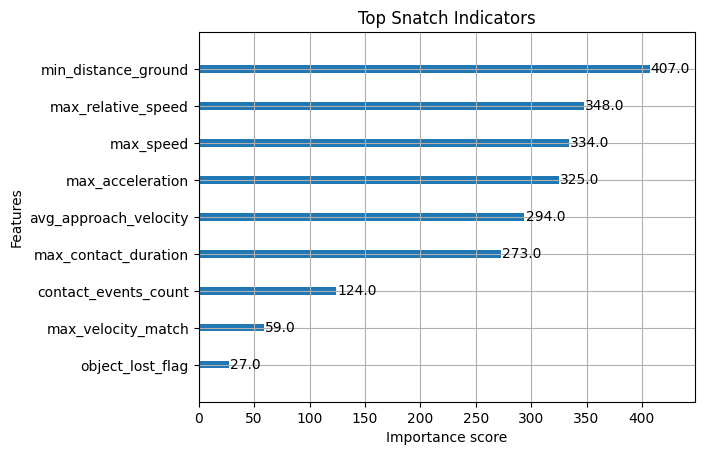

In [71]:
# ============================================================
# STEP 8: FEATURE IMPORTANCE
# ============================================================
plt.figure(figsize=(10, 6))
plot_importance(model, importance_type='weight', max_num_features=10, title="Top Snatch Indicators")
plt.show()

In [72]:
# ============================================================
# STEP 9: SAVE MODEL
# ============================================================
joblib.dump(model, "snatch_model.pkl")
print("\n✅ Model saved as snatch_model.pkl")


✅ Model saved as snatch_model.pkl
